[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/navjotts/ML-experiments/blob/master/7%20-%20What%20works%20on%20Kickstarter/What_works_on_Kickstarter%E2%80%8A_analysis.ipynb)

# Overview 

Around 15 million people all over the world have invested and backed interesting projects on Kickstarter, let’s see if we can analyze the data and find some trends.

We will be using the [Kickstarter dataset](https://www.kaggle.com/kemical/kickstarter-projects/data) from Kaggle for our exploratory exercise.


In [0]:
import matplotlib as mpl
mpl.rcParams['figure.dpi']= 100

# Step 1: Data Prep

In [10]:
import pandas as pd
import numpy as np

!wget https://www.dropbox.com/s/k80hx7utv13azsq/ks-projects-201612.csv?dl=0 -O kickstarter_data.csv
  
df = pd.read_csv('kickstarter_data.csv', encoding='ISO-8859-1')

# column names have trailing whitespace
df = df.rename(columns=lambda x: x.strip())

# drop the last 4 columns (gibberish data)
df.drop(['Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16'], axis=1, inplace=True)


# replace the missing 'name' and 'category' with placeholders
df['name'] = df['name'].fillna('Unknown Name')
df['category'] = df['category'].fillna('Unknown Category')

# we want some features to be in numerical form
numerical_features = ['goal', 'backers', 'usd pledged']
for feature in numerical_features:
  df[feature] = pd.to_numeric(df[feature], errors='coerce')

# this is not optimal, but we have enough data to play around with
df.dropna(axis=0, inplace=True)

df.head()

--2018-05-04 18:51:21--  https://www.dropbox.com/s/k80hx7utv13azsq/ks-projects-201612.csv?dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.7.1, 2620:100:6016:1::a27d:101
Connecting to www.dropbox.com (www.dropbox.com)|162.125.7.1|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://dl.dropboxusercontent.com/content_link/nabBbNfkoytB8kFtAPKZAlSsExKSR07aoevAsTX1ZvBbkU7gz1iCOPtcCxCdgnhN/file [following]
--2018-05-04 18:51:22--  https://dl.dropboxusercontent.com/content_link/nabBbNfkoytB8kFtAPKZAlSsExKSR07aoevAsTX1ZvBbkU7gz1iCOPtcCxCdgnhN/file
Resolving dl.dropboxusercontent.com (dl.dropboxusercontent.com)... 162.125.7.6, 2620:100:6016:6::a27d:106
Connecting to dl.dropboxusercontent.com (dl.dropboxusercontent.com)|162.125.7.6|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 46500324 (44M) [text/csv]
Saving to: ‘kickstarter_data.csv’

kickstarter_data.cs 100%[===================>]  44.35M  59.0MB/s    in 0.8s    

2018-05

/usr/local/lib/python3.6/dist-packages/IPython/core/interactiveshell.py:2718: DtypeWarning: Columns (13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09 11:36:00,1000.0,2015-08-11 12:12:28,0,failed,0.0,GB,0.0
1,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26 00:20:50,45000.0,2013-01-12 00:20:50,220,failed,3.0,US,220.0
2,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16 04:24:11,5000.0,2012-03-17 03:24:11,1,failed,1.0,US,1.0
3,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,USD,2015-08-29 01:00:00,19500.0,2015-07-04 08:35:03,1283,canceled,14.0,US,1283.0
4,1000014025,Monarch Espresso Bar,Restaurants,Food,USD,2016-04-01 13:38:27,50000.0,2016-02-26 13:38:27,52375,successful,224.0,US,52375.0


make a copy of the cleanup dataset (so that we don't have to repeat the above steps)

In [0]:
data_sample = df.copy()

# Step 2: Conduct Quantitative Data Analysis

In [0]:
def quantative_data_analysis(data, feature):
  data = data[feature]
  print("'" + feature + "'")
  print("min: ", data.min())
  print("max: ", data.max())
  print("mean: ", data.mean())
  print("median: ", data.median())
  print("standard deviation: ", data.std())
  print("--------------------")

In [5]:
features = ['goal', 'backers', 'usd pledged']

for each in features:
  quantative_data_analysis(data_sample, each)

'goal'
min:  0.01
max:  100000000.0
mean:  47647.878529192545
median:  5000.0
standard deviation:  1146303.7874453212
--------------------
'backers'
min:  0.0
max:  219382.0
mean:  102.84115079166249
median:  12.0
standard deviation:  940.3830983359336
--------------------
'usd pledged'
min:  0.0
max:  20338986.27
mean:  7847.678135049503
median:  535.0
standard deviation:  84684.0474648204
--------------------


**Lets pick some thresholds for these features, so that we can throw away the lower outliers and study a smaller sample**

In [0]:
# goal ~ (1000.0, 1000000.0)
# backers ~ (10, 5000)
# usd pledged ~ (100.0, 100000.0)
data_sample = data_sample[(data_sample['goal'] > 1000.0)  & 
                          (data_sample['goal'] < 100000.0) & 
                          (data_sample['backers'] > 10) & 
                          (data_sample['backers'] < 1000) & 
                          (data_sample['usd pledged'] > 100.0) &
                          (data_sample['usd pledged'] < 10000.0)]

# Step 3: Perform Graphical Data Analysis

### ECDFs, Histograms, Box Plots

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_ECDF(data, feature, percentiles=[]):  
  sample = data[feature]
  n = len(sample)  
  x = np.sort(sample)
  y = np.arange(1, n+1) / n
  plt.plot(x, y)
  plt.xlabel(feature)
  plt.title('ECDF for %s' % feature)
  
  if len(percentiles)>0:
    ptiles = np.percentile(sample, percentiles)
    plt.plot(ptiles, percentiles/100, marker='D', color='red', linestyle='none')

  plt.show();
  
def plot_histogram(data, feature):
  data = data[feature]
  plt.hist(data)
  plt.xlabel(feature)
  plt.title('Histogram for %s' % feature)
  plt.show();


def plot_box(data, feature_y, feature_x):
  fig, ax = plt.subplots()
  sns.boxplot(x=feature_x, y=feature_y, data=data)
  plt.xlabel(feature_x)
  plt.ylabel(feature_y)
  plt.xticks(rotation=45)
  plt.title('Box Plot (%s v/s %s)' % (feature_y, feature_x))
  plt.show();  

*Lets start with `goal` and `state`. It would be an interesting exercise to see what kind of relationship exists between deciding on your goal amount and being successfully getting funded.*

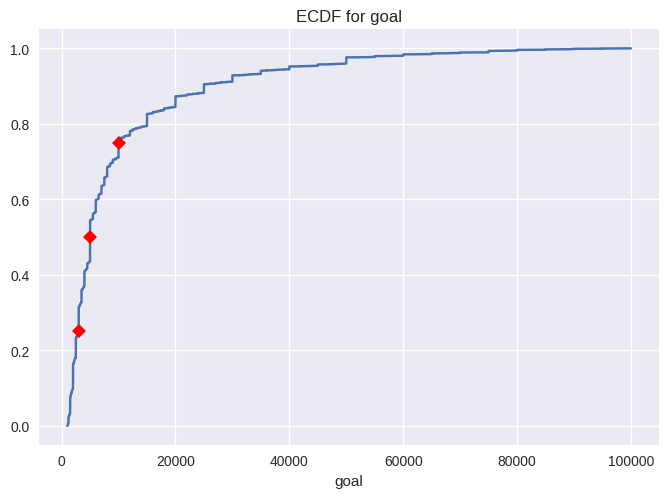

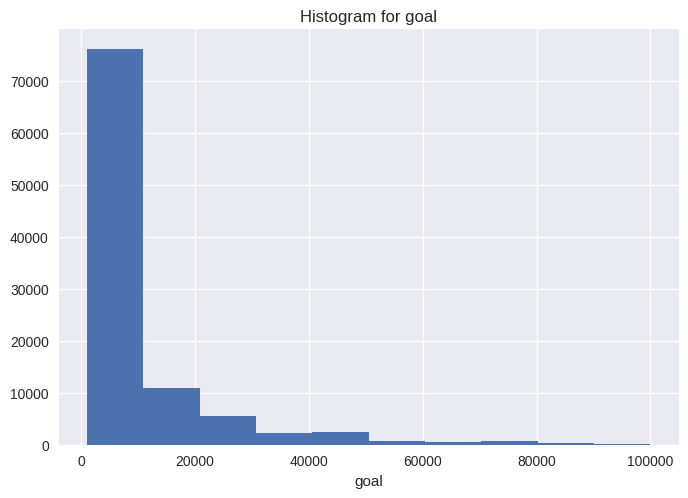

/usr/local/lib/python3.6/dist-packages/seaborn/categorical.py:454: FutureWarning: remove_na is deprecated and is a private function. Do not use.
  box_data = remove_na(group_data)


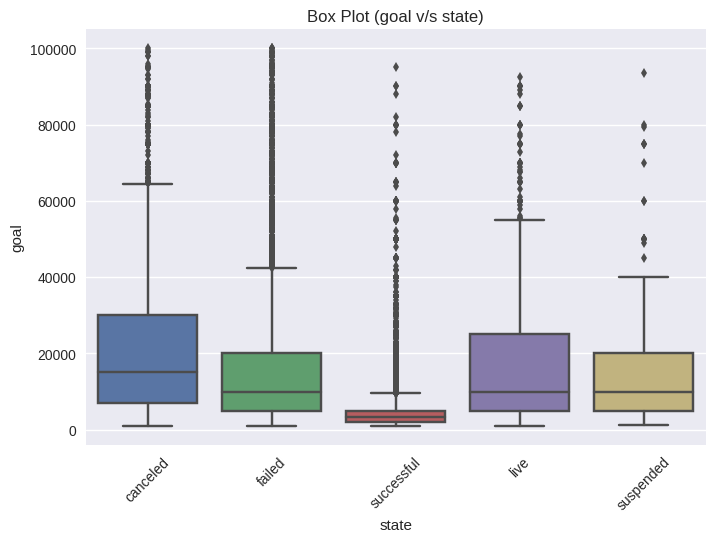

In [44]:
features = ['goal']

percentiles = np.array([25,50,75])
for each in features:
  plot_ECDF(data_sample, each, percentiles)

for each in features:
  plot_histogram(data_sample, each)
  
feature_pairs = [['goal', 'state']]

for f1, f2 in feature_pairs:  
  plot_box(data_sample, f1, f2)

**Observation:**

Even though there are outliers for successful, the Box Plot above clearly shows that the majority of the successful projects on Kickstarter are the ones with small funding goal in mind — something practical and not over-ambitious.

## Example 2

Let's study if there is any relationship b/w `state` and the `category` the project lies in

### Stacked Bar Chart

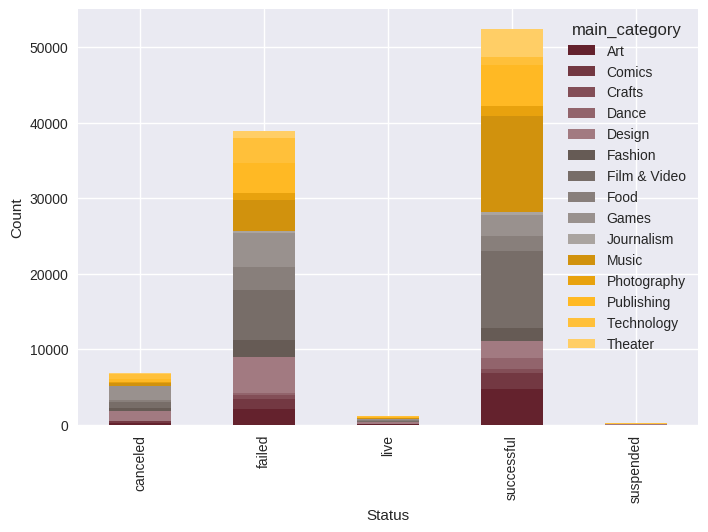

In [46]:
# create a color for each category
colors = ['#64222D', '#733842', '#834E57', '#92646C', '#A27A81',
          '#665B55', '#776D68', '#887F7B', '#99918E', '#AAA4A0', 
          '#D1920D', '#E8A20E', '#FFB924', '#FFC03A', '#FFCE66']

status_category = pd.crosstab(data_sample['state'], 
                              data_sample['main_category'])
status_category.plot.bar(stacked=True, color=colors)
plt.xlabel('Status')
plt.ylabel('Count');

**Observation:**

5 categories stand out: `Theater`, `Publishing`, `Music`, `File & Video`, and `Art`


# Conclusion

Only from the above 2 examples, we can have our basic intuition of what kind of projects are successful on Kickstarter — more Artist-y (art, music, video etc) and with a practical goal amount to achieve via funding.

One can run many such experiments with different permutation of features, and attempt to dissect more hidden relationships in the data.

